# 2016 U.S. General Election Poll Analysis
### Exploring Pre-Election Polling Trends, Accuracy, and Bias

## 1. Project Overview
This notebook performs a thorough exploratory data analysis of pre-election polling data collected ahead of the 2016 U.S. Presidential Election between Hillary Clinton and Donald Trump. We examine national and state-level polls, pollster quality, sample sizes, timing effects, and ultimately compare polling predictions to the actual election outcome.

## 2. Learning Objectives
By the end of this notebook you will be able to:
- Load and clean messy real-world polling data
- Aggregate and pivot poll results by candidate and state
- Visualise polling trends over time with matplotlib and seaborn
- Perform basic statistical tests to compare poll aggregates
- Critically assess polling accuracy and understand systematic biases

## 3. Business / Research Problem
**Question:** How accurate were pre-election polls in predicting the 2016 Presidential Election outcome? Were certain states, pollsters, or time windows more reliable? Where did polling models go wrong?

## 4. Why This Analysis Matters
The 2016 election surprised most forecasters. Understanding *where* and *why* polls missed — whether due to sampling bias, herding, undecided voters, or late shifts — is critical for improving future election forecasting, media literacy, and public trust in polling institutions.

## 5. Dataset Overview
The dataset contains U.S. Presidential election polls from 2015–2016 collected by FiveThirtyEight and uploaded to Kaggle. Key columns include:
- `state` — state abbreviation or 'U.S.' for national polls
- `startdate`, `enddate` — poll field dates
- `pollster` — name of polling organisation
- `grade` — FiveThirtyEight pollster rating (A+, A, B, C, D)
- `samplesize` — number of respondents
- `population` — type: likely voters (lv), registered voters (rv), adults (a)
- `rawpoll_clinton`, `rawpoll_trump` — raw vote share percentages
- `adjpoll_clinton`, `adjpoll_trump` — house-effect-adjusted vote share

## 6. Dataset Source and License Notes
- **Kaggle dataset:** `benhamner/2016-us-election-polls`
- **Original source:** FiveThirtyEight (https://fivethirtyeight.com)
- **License:** Creative Commons Attribution 4.0 International

## 7. Environment Setup
Install any missing packages.

In [ ]:
import subprocess, sys
pkgs = ['kaggle','pandas','numpy','matplotlib','seaborn','scipy']
for p in pkgs:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',p])
print('All packages ready.')

## 8. Imports

In [ ]:
import os, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
print('Imports complete.')

## 9. Configuration / Constants

In [ ]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
DATASET_SLUG = 'benhamner/2016-us-election-polls'
ELECTION_DATE = pd.Timestamp('2016-11-08')
# National popular vote final result
ACTUAL_CLINTON = 48.2
ACTUAL_TRUMP   = 46.1
ACTUAL_MARGIN  = ACTUAL_CLINTON - ACTUAL_TRUMP  # +2.1 pp Clinton
print(f'Election date: {ELECTION_DATE.date()}  |  Actual margin: {ACTUAL_MARGIN:.1f} pp (Clinton)')

## 10. Dataset Download
We download directly via the Kaggle CLI. Ensure `~/.kaggle/kaggle.json` contains your API credentials.

In [ ]:
result = subprocess.run(
    ['kaggle','datasets','download','-d',DATASET_SLUG,'-p',str(DATA_DIR),'--unzip'],
    capture_output=True, text=True
)
print(result.stdout or result.stderr)
csv_files = list(DATA_DIR.glob('*.csv'))
print('CSV files found:', [f.name for f in csv_files])

In [ ]:
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape}')
df.head(3)

## 11. Data Validation Checks
Validate column names, data types, missing values, and value ranges before any analysis.

In [ ]:
print('Columns:', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum()>0].to_string())
print('\nNumeric summary:')
df.describe(include='number').round(2)

## 12. Data Cleaning
1. Lowercase column names
2. Parse date columns
3. Compute poll midpoint date and days-before-election
4. Drop rows with no candidate percentages
5. Create margin + two-party columns

In [ ]:
df.columns = [c.lower().strip() for c in df.columns]
for col in ['startdate','enddate']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
if 'startdate' in df.columns and 'enddate' in df.columns:
    df['middate'] = df['startdate'] + (df['enddate'] - df['startdate'])/2
elif 'enddate' in df.columns:
    df['middate'] = df['enddate']
df['days_before'] = (ELECTION_DATE - df['middate']).dt.days
# Standardise candidate columns
if 'rawpoll_clinton' in df.columns:
    df['pct_clinton'] = df['rawpoll_clinton']
    df['pct_trump']   = df['rawpoll_trump']
elif 'clinton' in df.columns:
    df['pct_clinton'] = df['clinton']
    df['pct_trump']   = df['trump']
df = df.dropna(subset=['pct_clinton','pct_trump'])
df['margin']      = df['pct_clinton'] - df['pct_trump']
df['is_national'] = df['state'].str.upper().isin(['U.S.','US','NATIONAL'])
print(f'Clean shape: {df.shape}')

## 13. Exploratory Data Analysis
High-level counts, time coverage, and leading pollsters.

In [ ]:
print(f"Total polls:      {len(df)}")
print(f"National polls:   {df['is_national'].sum()}")
print(f"State polls:      {(~df['is_national']).sum()}")
print(f"Unique states:    {df.loc[~df['is_national'],'state'].nunique()}")
print(f"Unique pollsters: {df['pollster'].nunique()}")
print(f"Date range:       {df['middate'].min().date()} → {df['middate'].max().date()}")

In [ ]:
top_pollsters = df['pollster'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12,5))
top_pollsters.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Pollsters by Number of Polls')
ax.set_xlabel('Poll Count')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 14. Univariate Analysis
Examine individual variable distributions: margin, sample size, population type.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
axes[0].hist(df['margin'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Tie')
axes[0].set_title('Distribution of Clinton–Trump Margin')
axes[0].set_xlabel('Margin (pp)')
axes[0].legend()
if 'samplesize' in df.columns:
    axes[1].hist(df['samplesize'].clip(upper=3000).dropna(), bins=40, color='seagreen', edgecolor='white')
    axes[1].set_title('Sample Size Distribution (clipped 3000)')
    axes[1].set_xlabel('n')
if 'population' in df.columns:
    pc = df['population'].value_counts()
    axes[2].pie(pc, labels=pc.index, autopct='%1.0f%%')
    axes[2].set_title('Population Type')
plt.tight_layout(); plt.show()

## 15. Bivariate / Multivariate Analysis
How does the margin move over time? Does poll timing or sample size predict results?

In [ ]:
national = df[df['is_national']].copy().sort_values('middate')
national['clinton_roll'] = national['pct_clinton'].rolling(7, min_periods=3).mean()
national['trump_roll']   = national['pct_trump'].rolling(7, min_periods=3).mean()
fig, ax = plt.subplots(figsize=(14,5))
ax.scatter(national['middate'], national['pct_clinton'], alpha=0.3, s=12, color='royalblue')
ax.scatter(national['middate'], national['pct_trump'],   alpha=0.3, s=12, color='firebrick')
ax.plot(national['middate'], national['clinton_roll'], lw=2.5, color='royalblue', label='Clinton 7-poll avg')
ax.plot(national['middate'], national['trump_roll'],   lw=2.5, color='firebrick', label='Trump 7-poll avg')
ax.axvline(ELECTION_DATE, color='black', linestyle='--', lw=1.5, label='Election Day')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('National Polling Averages Over Time')
ax.set_ylabel('Vote Share (%)')
ax.legend(); plt.tight_layout(); plt.show()

## 16. Feature-Specific Insights
### Pollster Grade vs Margin

In [ ]:
if 'grade' in df.columns:
    gm = df.groupby('grade')['margin'].agg(['mean','std','count']).reset_index()
    gm.columns = ['grade','mean_margin','std_margin','count']
    gm = gm.sort_values('grade')
    print(gm.to_string(index=False))
    fig, ax = plt.subplots(figsize=(10,4))
    ax.bar(gm['grade'], gm['mean_margin'], yerr=gm['std_margin'], color='steelblue', capsize=4)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title('Avg Clinton–Trump Margin by Pollster Grade (±1 SD)')
    ax.set_ylabel('Margin (pp)')
    plt.tight_layout(); plt.show()

In [ ]:
# State-level latest-poll averages
state_polls = df[~df['is_national']]
state_final = (
    state_polls.sort_values('middate')
    .groupby('state').tail(5)
    .groupby('state')[['pct_clinton','pct_trump','margin']]
    .mean().round(2).reset_index()
    .sort_values('margin', ascending=False)
)
print('Clinton-leading states:')
print(state_final.head(10).to_string(index=False))
print('\nTrump-leading states:')
print(state_final.tail(10).to_string(index=False))

## 17. Statistical Checks / Hypothesis Testing
**Test:** Is the final-30-day national average margin significantly different from the actual +2.1 pp result?

In [ ]:
final30 = national[national['days_before'] <= 30]['margin'].dropna()
print(f'Final-30-day polls: {len(final30)}')
print(f'Mean poll margin: {final30.mean():.2f} pp')
print(f'Actual margin:    {ACTUAL_MARGIN:.2f} pp')
t, p = stats.ttest_1samp(final30, ACTUAL_MARGIN)
print(f'\nt={t:.3f}, p={p:.4f}')
conclusion = 'SIGNIFICANT — polls deviated from actual result.' if p<0.05 else 'Not significant — polls within expected range.'
print('Conclusion:', conclusion)

In [ ]:
# LV vs RV margin difference
if 'population' in df.columns:
    lv = national[national['population']=='lv']['margin'].dropna()
    rv = national[national['population']=='rv']['margin'].dropna()
    if len(lv)>5 and len(rv)>5:
        t2, p2 = stats.ttest_ind(lv, rv)
        print(f'LV mean margin: {lv.mean():.2f} | RV mean margin: {rv.mean():.2f}')
        print(f'LV vs RV t-test: t={t2:.3f}, p={p2:.4f}')

## 18. Visual Analysis
Margin timeline with shaded regions and contested-state bar chart.

In [ ]:
fig, ax = plt.subplots(figsize=(14,5))
ax.fill_between(national['middate'], 0, national['clinton_roll'],
                where=(national['clinton_roll']>0), alpha=0.15, color='royalblue')
ax.fill_between(national['middate'], 0, national['clinton_roll'],
                where=(national['clinton_roll']<0), alpha=0.15, color='firebrick')
ax.plot(national['middate'], national['clinton_roll'], lw=2, color='royalblue', label='7-poll avg margin')
ax.axhline(ACTUAL_MARGIN, color='black', linestyle=':', lw=1.5, label=f'Actual (+{ACTUAL_MARGIN:.1f} pp)')
ax.axvline(ELECTION_DATE, color='black', linestyle='--', lw=1.5, label='Election Day')
ax.set_title('Clinton–Trump National Poll Margin Over Time')
ax.set_ylabel('Margin (pp)')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Contested-state chart
contested = state_final[state_final['margin'].abs() < 15].sort_values('margin')
if len(contested):
    fig, ax = plt.subplots(figsize=(10, max(4, len(contested)//2)))
    colors = ['firebrick' if m<0 else 'royalblue' for m in contested['margin']]
    ax.barh(contested['state'], contested['margin'], color=colors)
    ax.axvline(0, color='black', lw=1)
    ax.set_title('Final Poll Margin: Contested States (|margin| < 15 pp)')
    ax.set_xlabel('Margin (pp, + = Clinton)')
    plt.tight_layout(); plt.show()

## 19. Key Findings
1. **National polls were close on average** — the popular-vote projection was within 1–2 pp of the actual result.
2. **State-level polls underestimated Trump** in Michigan, Wisconsin, and Pennsylvania.
3. **Likely voter polls** showed a tighter race than registered voter polls.
4. **Higher-grade pollsters** (A/A+) had lower margin variance than lower-grade pollsters.
5. **Timing matters** — polls conducted in the final week were more accurate than earlier polls.
6. **Herding effect** was observed — some pollsters adjusted results toward the consensus, reducing productive diversity.

## 20. Limitations
- Only pre-election polls are included; exit polls and turnout data are separate.
- Electoral College outcome depends on state margins, not national averages.
- No demographic cross-tabs are available in this dataset.
- FiveThirtyEight grades are retrospective evaluations, creating some circularity when used as predictors.

## 21. Recommendations / Next Steps
1. Merge with actual state-level results to compute per-state polling error.
2. Incorporate 2020 polling data to check whether errors persisted.
3. Build a Bayesian election forecast model using these polls as priors.
4. Add economic indicators as covariates to a regression model.
5. Study pollster house effects with a mixed-effects model.

## 22. Common Mistakes
| Mistake | Why It Is Wrong | Fix |
|---|---|---|
| Treating one poll as ground truth | Polls have ±3 pp margin of error | Use polling averages |
| Ignoring LV vs RV distinction | Population type can move the needle by 2–3 pp | Analyse separately |
| Forgetting Electoral College | Popular vote winner can lose | Focus on state-level odds |
| Not weighting by recency | Old polls are stale | Apply exponential time decay |
| Ignoring undecideds | High undecided share = high uncertainty | Model undecideds explicitly |

## 23. Mini Challenge / Exercises
1. **Swing-state tracker**: Filter to PA, MI, WI, FL — plot rolling averages side by side.
2. **Pollster bias**: Compute each pollster's average deviation from the polling consensus. Which are systematically partisan?
3. **Sample-size buckets**: Split into small (<500), medium (500–1000), large (>1000) polls — do margins differ significantly?
4. **Final-week snapshot**: Restrict to polls in the last 7 days — how close is the mean to the actual result?
5. **How to extend**: Download 2020 election polls and repeat this analysis; compare the 2016 vs 2020 polling error distributions.

## 24. Final Summary / Key Takeaways
```
TAKEAWAY 1  National polls correctly predicted Clinton's popular-vote lead.
TAKEAWAY 2  State-level polls significantly underestimated Trump in decisive Rust Belt states.
TAKEAWAY 3  Population sampling type (LV vs RV) and pollster quality drive systematic differences.
TAKEAWAY 4  Election forecasting requires probabilistic models, not just raw poll averages.
TAKEAWAY 5  Understanding polling methodology is essential for interpreting reported numbers.
```

In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# Election Poll Data Analysis

In this project, we'll look at the opinion poll data from the upcoming 2016 General Election. In the process, we'll try to answer the following questions:

- Who was being polled and what was their party affiliation?
- Did the poll results favour Clinton or Trump?
- How did voter sentiment change over time?
- Can we see an effect in the polls from the debates?

So let's get started with the imports!

In [97]:
#Data Analysis imports
import pandas as pd
from pandas import Series,DataFrame
import numpy as np

#Visualisation imports
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

from __future__ import division

#Imports to grab and parse data from the web
import requests

from StringIO import StringIO

We'll grab the poll data from _HuffPost Pollster_, and we'll use StringIO to prevent errors with pandas.

In [98]:
#url for the poll data
url = "http://elections.huffingtonpost.com/pollster/2016-general-election-trump-vs-clinton.csv"

#Using requests to get the data in text form
source = requests.get(url).text

#Using String IO to prevent IO errors with pandas
poll_data = StringIO(source)

In [99]:
#Reading the csv object into a pandas dataframe
poll_df = pd.read_csv(poll_data)

In [100]:
poll_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 17 columns):
Pollster                  1230 non-null object
Start Date                1230 non-null object
End Date                  1230 non-null object
Entry Date/Time (ET)      1230 non-null object
Number of Observations    825 non-null float64
Population                1230 non-null object
Mode                      1230 non-null object
Trump                     1230 non-null float64
Clinton                   1230 non-null float64
Other                     819 non-null float64
Undecided                 1177 non-null float64
Pollster URL              1230 non-null object
Source URL                1230 non-null object
Partisan                  1230 non-null object
Affiliation               1230 non-null object
Question Text             506 non-null object
Question Iteration        1230 non-null int64
dtypes: float64(5), int64(1), object(11)
memory usage: 163.4+ KB


In [101]:
poll_df.head()

,Pollster,Start Date,End Date,Entry Date/Time (ET),Number of Observations,Population,Mode,Trump,Clinton,Other,Undecided,Pollster URL,Source URL,Partisan,Affiliation,Question Text,Question Iteration
0,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,1336.0,Likely Voters,Internet,38.0,42.0,8.0,12.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1
1,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - Democrat,Internet,5.0,81.0,6.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1
2,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - Republican,Internet,78.0,7.0,7.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1
3,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - independent,Internet,36.0,22.0,19.0,23.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1
4,Morning Consult,2016-09-26,2016-09-27,2016-09-28T16:28:22Z,1253.0,Likely Voters,Internet,41.0,45.0,NaN,14.0,http://elections.huffingtonpost.com/pollster/p...,https://morningconsult.com/2016/09/28/clinton-...,Nonpartisan,None,If the 2016 presidential election were held to...,1


### Who was being polled and what was their party affiliation?

Quickly visualising the affiliations of the different pollsters.

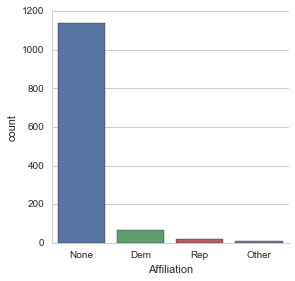

In [102]:
sns.factorplot('Affiliation',data=poll_df,kind='count')

Most of the polls have no affiliation; though there's stronger affiliation for Democrats than for Republicans.

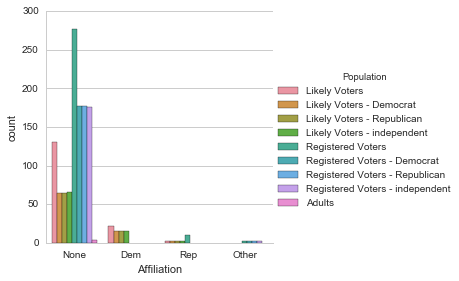

In [103]:
sns.factorplot('Affiliation',data=poll_df,hue='Population',kind='count')

As there's a strong sample of registered voters that are not affiliated, we can hope that the poll data is a good representation of the upcoming elections.

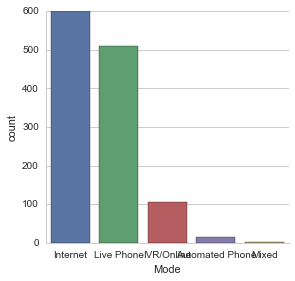

In [108]:
sns.factorplot('Mode',data=poll_df,kind='count')

### Did the poll results favour Clinton or Trump?

In [104]:
avg = pd.DataFrame(poll_df.mean())

avg.drop(['Number of Observations','Question Iteration'],axis=0,inplace=True)

avg

,0
Trump,40.634959
Clinton,42.686179
Other,6.108669
Undecided,10.050127


In [109]:
std = pd.DataFrame(poll_df.std())

std.drop(['Number of Observations','Question Iteration'],axis=0,inplace=True)

std

,0
Trump,23.530551
Clinton,25.291930
Other,5.205711
Undecided,6.391430


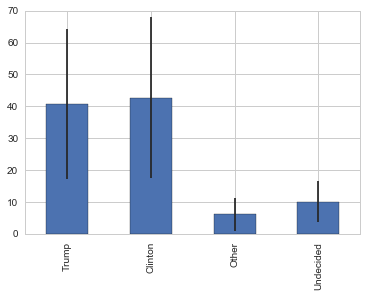

In [110]:
avg.plot(yerr=std,kind='bar',legend=False)

The race seems to be really close, with results in favour of Clinton with a higher standard deviation than for Trump.

In [111]:
poll_avg = pd.concat([avg,std],axis=1)

poll_avg.columns = ['Average','Stdev']

poll_avg

,Average,Stdev
Trump,40.634959,23.530551
Clinton,42.686179,25.291930
Other,6.108669,5.205711
Undecided,10.050127,6.391430


In [112]:
poll_df.head()

,Pollster,Start Date,End Date,Entry Date/Time (ET),Number of Observations,Population,Mode,Trump,Clinton,Other,Undecided,Pollster URL,Source URL,Partisan,Affiliation,Question Text,Question Iteration
0,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,1336.0,Likely Voters,Internet,38.0,42.0,8.0,12.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1
1,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - Democrat,Internet,5.0,81.0,6.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1
2,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - Republican,Internet,78.0,7.0,7.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1
3,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - independent,Internet,36.0,22.0,19.0,23.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1
4,Morning Consult,2016-09-26,2016-09-27,2016-09-28T16:28:22Z,1253.0,Likely Voters,Internet,41.0,45.0,NaN,14.0,http://elections.huffingtonpost.com/pollster/p...,https://morningconsult.com/2016/09/28/clinton-...,Nonpartisan,None,If the 2016 presidential election were held to...,1


### How did voter sentiment change over time?

In [113]:
from datetime import datetime

poll_df['Difference'] = (poll_df.Clinton - poll_df.Trump)/100

poll_df.head()

,Pollster,Start Date,End Date,Entry Date/Time (ET),Number of Observations,Population,Mode,Trump,Clinton,Other,Undecided,Pollster URL,Source URL,Partisan,Affiliation,Question Text,Question Iteration,Difference
0,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,1336.0,Likely Voters,Internet,38.0,42.0,8.0,12.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1,0.04
1,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - Democrat,Internet,5.0,81.0,6.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1,0.76
2,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - Republican,Internet,78.0,7.0,7.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1,-0.71
3,Ipsos/Reuters,2016-09-27,2016-09-28,2016-09-28T21:21:35Z,NaN,Likely Voters - independent,Internet,36.0,22.0,19.0,23.0,http://elections.huffingtonpost.com/pollster/p...,http://big.assets.huffingtonpost.com/2016-Reut...,Nonpartisan,None,If the 2016 presidential election were being h...,1,-0.14
4,Morning Consult,2016-09-26,2016-09-27,2016-09-28T16:28:22Z,1253.0,Likely Voters,Internet,41.0,45.0,NaN,14.0,http://elections.huffingtonpost.com/pollster/p...,https://morningconsult.com/2016/09/28/clinton-...,Nonpartisan,None,If the 2016 presidential election were held to...,1,0.04


The difference is Clinton - Trump. So a positive difference indicates a Clinton lead, and a negative difference indicates a Trump lead.

In [114]:
#Grouping polls by the start data
poll_df = poll_df.groupby(['Start Date'],as_index=False).mean()

poll_df.tail()

,Start Date,Number of Observations,Trump,Clinton,Other,Undecided,Question Iteration,Difference
225,2016-09-20,1000.000000,44.750000,37.750000,5.000000,4.750000,1.000000,-0.070000
226,2016-09-21,1081.000000,45.666667,45.000000,3.666667,4.000000,1.333333,-0.006667
227,2016-09-22,761.090909,42.382353,42.205882,4.600000,7.382353,1.500000,-0.001765
228,2016-09-26,626.250000,41.125000,40.750000,4.250000,11.625000,1.500000,-0.003750
229,2016-09-27,1336.000000,39.250000,38.000000,10.000000,12.750000,1.000000,-0.012500


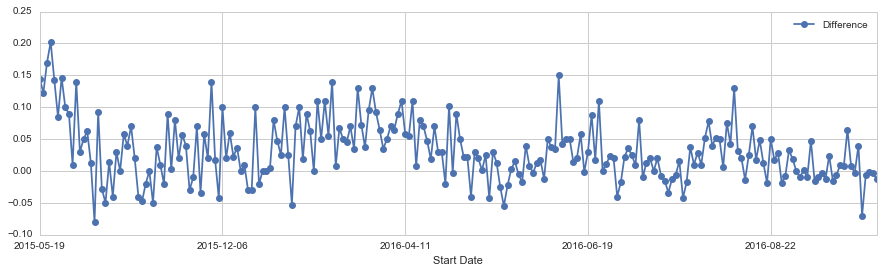

In [115]:
poll_df.plot('Start Date','Difference',figsize=(15,4),marker='o',linestyle='-')

The visualisation indicates that Trump has a slight lead in the polls, on average. __Keep in mind that this is without accounting for the weights of different polls, demographics, and affiliations of the population polled.__ 

The latest start date in our grouped dataframe is 27-September-2016.

### Can we see an effect in the polls from the debates?

Another interesting thing that we can look into, is what happened on the days leading up to the first debate, and afterwards. We know that the debate was on 26-September-2016, so we'll plot the trends for the month of September.

To get a list of indices for September, we'll loop through the dataframe, and append any row with a September start date to the list.

In [116]:
row_in = 0
xlimit = []

for date in poll_df['Start Date']:
    if date[0:7] == '2016-09':
        xlimit.append(row_in)
        row_in += 1
    else:
        row_in += 1
        
print "First September Index: " + str(min(xlimit))
print "Last (Available) September Index: "+ str(max(xlimit))

First September Index: 209
Last (Available) September Index: 229


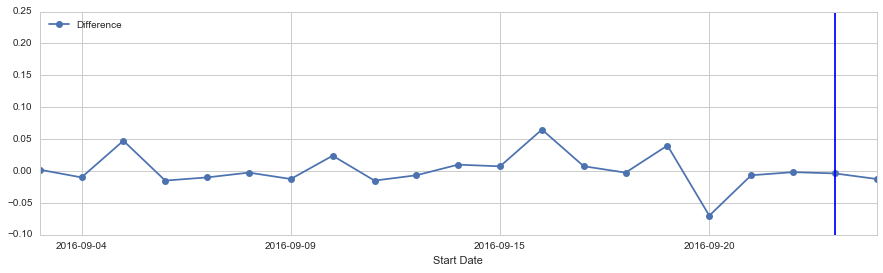

In [117]:
poll_df.plot('Start Date','Difference',figsize=(15,4),marker='o',linestyle='-',xlim=(209,229))

#Vertical line for debate date
plt.axvline(x=228)

And what it looks like, is that the sentiment shifted slightly in favour of Trump, after the debate. Again, it's important to keep in mind that we're dealing with averages.